# Stage-1 BO replay on the 303×317 contour grids (prompt 21)

**Claim scope (math-log §5.1):** Stage 1 validates the BO *machinery* on a smooth
2-D, 81-candidate problem where the truth is known; the difficulty claim lives in
Stage 2 (continuous d = 6, fresh PCM runs). Nothing here is the headline's difficulty.

Candidate set = the 81 evaluated designs per scenario (`waves/contour_303x317_{A,B,C}`);
every "evaluation" is a table lookup. All objectives minimized (Δ vs base).

**No-leakage rule (hard):** inside every loop the GP, its hyperparameters and the
input/output scalers are fit ONLY on the queried points. The only full-table
quantities are metric definitions (grid-min + floor; HV ideal/nadir/reference).

Run (needs bo-gp branch `feat/qparego` on `PYTHONPATH` for `hypervolume_exact` and
the shared q-ParEGO scalarization):

```
cd trial_0826/campaign/analysis/bo_replay
PYTHONPATH=/path/to/bo-gp /opt/anaconda3/envs/bogp/bin/jupyter nbconvert --to notebook --execute --inplace bo_replay.ipynb
```


In [1]:
import json, re, sys, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"font.weight": "bold", "axes.labelweight": "bold", "axes.titleweight": "bold"})
from joblib import Parallel, delayed

import replay as R
from bogp.mobo.pareto import hypervolume, hypervolume_exact
from bogp.mobo import qparego as QP
from bogp.evaluators.multi_grid import MultiGridEvaluator

FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
T0 = time.time()
BO_SEEDS, RAND_SEEDS = list(R.BO_SEEDS), list(R.RANDOM_SEEDS)
FLOORS = R.floors()
COL = {"BO": "#2a78d6", "random": "#eb6834", "Sobol": "#1baf7a"}   # dataviz slots 1-3 (validated all-pairs)
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5})
print("BO seeds:", len(BO_SEEDS), "| random seeds:", len(RAND_SEEDS), "| Sobol seed:", R.SOBOL_SEED, "| init:", R.N_INIT)
print("floors:", {R.SHORT[k]: v for k, v in FLOORS.items()}, "(starts = WORKING floor)")
DATA = {t: R.load_scenario(t) for t in R.SCENARIOS}
XY = {t: R.xy(DATA[t]) for t in R.SCENARIOS}
RESULTS = {"seeds": {"bo": BO_SEEDS, "random": RAND_SEEDS, "sobol": R.SOBOL_SEED, "n_init": R.N_INIT},
           "floors": {R.SHORT[k]: v for k, v in FLOORS.items()}}

BO seeds: 20 | random seeds: 100 | Sobol seed: 20260821 | init: 5
floors: {'cost': 500000.0, 'curt': 5000.0, 'shed': 3000.0, 'starts': 60.0} (starts = WORKING floor)


## 1. Surfaces, fronts, degeneracy (honesty exhibit)

In [2]:
rows = []
for t in R.SCENARIOS:
    X, Y = XY[t]
    for j, o in enumerate(R.OBJECTIVES):
        s = R.quadratic_fit_stats(X, Y[:, j])
        rows.append(dict(scenario=t, metric=R.SHORT[o], quad_r2=s["r2"], quad_rmse_dof=s["rmse_dof"],
                         quad_rmse_n=s["rmse_n"], grid_min=Y[:, j].min(), grid_max=Y[:, j].max(),
                         floor=FLOORS[o], n_cells_within_floor=int((Y[:, j] <= Y[:, j].min() + FLOORS[o]).sum())))
surf = pd.DataFrame(rows); surf.to_csv("surface_stats.csv", index=False)
print(surf.round(4).to_string(index=False))
st = surf[surf.metric == "starts"]
print("\nstarts quadratic residual RMSE (dof n-6):", st.quad_rmse_dof.round(1).tolist(),
      "| (÷n):", st.quad_rmse_n.round(1).tolist(), "-> WORKING floor", R.STARTS_WORKING_FLOOR)
RESULTS["surface_stats"] = surf.to_dict("records")

scenario metric  quad_r2  quad_rmse_dof  quad_rmse_n      grid_min      grid_max    floor  n_cells_within_floor
       A   cost   0.9978    341877.5189  328971.7959 -3.216795e+07 -3.324272e+06 500000.0                     1
       A   curt   0.9921     23806.3218   22907.6438 -1.351128e+06 -1.888493e+05   5000.0                     2
       A   shed   0.6272      1712.6130    1647.9627 -1.210930e+04  6.194783e+02   3000.0                    20
       A starts   0.8740        54.6088      52.5474 -7.060000e+02 -4.000000e+00     60.0                     8
       B   cost   0.9980    417551.5765  401789.1918  4.451115e+06  4.014292e+07 500000.0                     1
       B   curt   0.9882     26327.9624   25334.0936 -1.243651e+06 -1.891098e+05   5000.0                     2
       B   shed   0.9764      1232.4295    1185.9058 -3.387043e+04 -2.326308e+02   3000.0                    12
       B starts   0.9725        56.2000      54.0785 -1.712000e+03 -2.620000e+02     60.0               

In [3]:
rows = []
for t in R.SCENARIOS:
    X, Y = XY[t]
    m4 = R.front_mask(Y); m2 = R.front_mask(Y[:, [0, 2]])
    corner = int(np.flatnonzero((X[:, 0] == X[:, 0].max()) & (X[:, 1] == X[:, 1].max()))[0])
    wd = R.weakly_dominated_by(Y, corner)
    # cost-shed front cells that sit within BOTH floors of the best cost-shed front cell
    f2 = np.flatnonzero(m2); Yf = Y[f2][:, [0, 2]]
    within = int(np.sum(np.all(Yf <= Yf.min(axis=0) + np.array([FLOORS[R.OBJECTIVES[0]], FLOORS[R.OBJECTIVES[2]]]), axis=1)))
    rows.append(dict(scenario=t, front_M4=int(m4.sum()), front_cost_shed=int(m2.sum()),
                     corner_11_weakly_dominates=f"{wd + 1}/81 (incl. itself)", cost_shed_front_cells_within_floors_of_best=within))
fronts = pd.DataFrame(rows); fronts.to_csv("front_stats.csv", index=False)
print(fronts.to_string(index=False))
print("\nexpected (19b / prompt 21): cost-shed ≈ 4 / 23 / 24; M=4 ≈ 15 / 71 / 73 (4-D non-domination inflates cardinality; do not 'fix').")
RESULTS["fronts"] = fronts.to_dict("records")

scenario  front_M4  front_cost_shed corner_11_weakly_dominates  cost_shed_front_cells_within_floors_of_best
       A        15                4       54/81 (incl. itself)                                            1
       B        71               23        1/81 (incl. itself)                                            0
       C        73               24        1/81 (incl. itself)                                            0

expected (19b / prompt 21): cost-shed ≈ 4 / 23 / 24; M=4 ≈ 15 / 71 / 73 (4-D non-domination inflates cardinality; do not 'fix').


## 2. Single-objective replay: BO (EI) vs random vs Sobol

In [4]:
t0 = time.time()
ORD = {}   # (scenario, metric) -> dict of orderings
for t in R.SCENARIOS:
    X, Y = XY[t]
    sob = R.sobol_order(X)
    assert len(set(sob)) == 81
    for j, o in enumerate(R.OBJECTIVES):
        bo = Parallel(n_jobs=-1)(delayed(R.bo_single_order)(X, Y[:, j], s) for s in BO_SEEDS)
        rnd = [R.random_order(81, s) for s in RAND_SEEDS]
        ORD[(t, o)] = {"BO": bo, "random": rnd, "Sobol": [sob]}
print(f"single-objective orderings: {time.time() - t0:.0f} s")

def eto_table(floor_override=None):
    rows = []
    for (t, o), d in ORD.items():
        y = XY[t][1][:, R.OBJECTIVES.index(o)]
        fl = FLOORS[o] if floor_override is None or o != "delta_thermal_starts" else floor_override
        r = dict(scenario=t, metric=R.SHORT[o], floor=fl)
        for k in ("BO", "random", "Sobol"):
            e = np.array([R.evals_to_optimum(od, y, fl) for od in d[k]])
            s = R.summarize(e)
            r[f"{k}_median"] = s["median"]; r[f"{k}_IQR"] = f"{s['q25']:.0f}–{s['q75']:.0f}"; r[f"{k}_max"] = s["max"]
        rows.append(r)
    return pd.DataFrame(rows)

eto = eto_table(); eto.to_csv("evals_to_optimum.csv", index=False)
print(eto.to_string(index=False))
RESULTS["evals_to_optimum"] = eto.to_dict("records")

single-objective orderings: 67 s
scenario metric    floor  BO_median BO_IQR  BO_max  random_median random_IQR  random_max  Sobol_median Sobol_IQR  Sobol_max
       A   cost 500000.0        6.0    6–7    15.0           46.0      20–60        80.0          76.0     76–76       76.0
       A   curt   5000.0        6.0    6–7    10.0           26.0      15–45        73.0          66.0     66–66       66.0
       A   shed   3000.0        3.0    1–6     8.0            3.0        2–5        15.0           2.0       2–2        2.0
       A starts     60.0        7.5   5–11    20.0            6.5       2–12        37.0          11.0     11–11       11.0
       B   cost 500000.0        6.0    6–7     8.0           37.5      20–61        81.0          77.0     77–77       77.0
       B   curt   5000.0        6.0    6–7    10.0           26.0      15–45        73.0          66.0     66–66       66.0
       B   shed   3000.0        5.5    3–6     8.0            5.0        3–9        41.0           

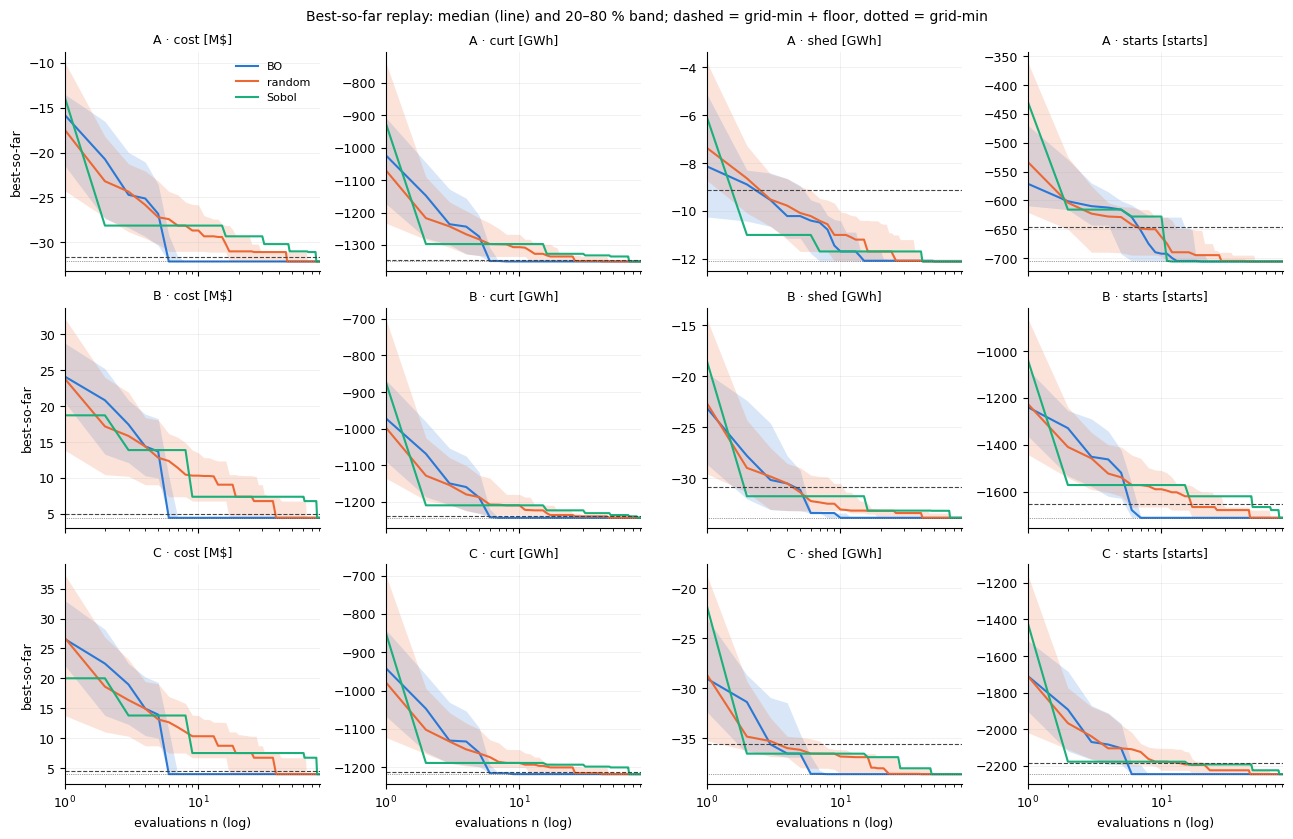

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(13, 8.5), sharex=True)
n = np.arange(1, 82)
for i, t in enumerate(R.SCENARIOS):
    for j, o in enumerate(R.OBJECTIVES):
        ax = axes[i, j]; y = XY[t][1][:, j]; sc = R.SCALE[R.SHORT[o]]
        for k in ("BO", "random", "Sobol"):
            curves = np.array([R.best_so_far(od, y) for od in ORD[(t, o)][k]]) * sc
            med, lo, hi = R.band(curves)
            ax.plot(n, med, color=COL[k], lw=1.5, label=k)
            if k != "Sobol":
                ax.fill_between(n, lo, hi, color=COL[k], alpha=0.18, lw=0)
        ax.axhline((y.min() + FLOORS[o]) * sc, color="#444", lw=0.8, ls="--")
        ax.axhline(y.min() * sc, color="#444", lw=0.5, ls=":")
        ax.set_xscale("log"); ax.set_xlim(1, 81)
        ax.set_title(f"{t} · {R.SHORT[o]} [{R.UNITS[R.SHORT[o]]}]", fontsize=9)
        if i == 2: ax.set_xlabel("evaluations n (log)")
        if j == 0: ax.set_ylabel("best-so-far")
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper right")
fig.suptitle("Best-so-far replay: median (line) and 20–80 % band; dashed = grid-min + floor, dotted = grid-min", fontsize=10)
fig.tight_layout()
for ext in ("pdf", "png"): fig.savefig(FIGS / f"fig1_best_so_far.{ext}", dpi=150)
plt.show()

### 2b. Starts working-floor sensitivity (floor ∈ {30, 60, 120})

In [6]:
rows = []
for fl in R.STARTS_FLOOR_SENSITIVITY:
    sub = eto_table(floor_override=fl); sub = sub[sub.metric == "starts"].copy(); sub["floor"] = fl
    rows.append(sub)
sens = pd.concat(rows).sort_values(["scenario", "floor"]); sens.to_csv("starts_floor_sensitivity.csv", index=False)
print(sens.to_string(index=False))
RESULTS["starts_floor_sensitivity"] = sens.to_dict("records")

scenario metric  floor  BO_median BO_IQR  BO_max  random_median random_IQR  random_max  Sobol_median Sobol_IQR  Sobol_max
       A starts   30.0        9.0   6–15    20.0           12.0       4–22        50.0          11.0     11–11       11.0
       A starts   60.0        7.5   5–11    20.0            6.5       2–12        37.0          11.0     11–11       11.0
       A starts  120.0        1.5    1–3     7.0            2.0        1–3         9.0           2.0       2–2        2.0
       B starts   30.0        7.0    6–7    14.0           46.0      20–60        80.0          76.0     76–76       76.0
       B starts   60.0        6.0    6–7    14.0           17.0      10–26        57.0          48.0     48–48       48.0
       B starts  120.0        6.0    4–6    10.0           11.0       4–18        48.0          16.0     16–16       16.0
       C starts   30.0        6.0    6–8    10.0           22.5      12–40        75.0          48.0     48–48       48.0
       C starts   60.0  

## 3. Multi-objective replay (M = 4): sequential ParEGO vs random vs Sobol

Hypervolume recovery n ↦ HV(first n queried) / HV(all 81); reference =
nadir + 0.1 × (nadir − ideal) per objective on the full 81 (the reference defines
the metric, not the optimizer's information). Exact HV (`hypervolume_exact`), never
Monte-Carlo.

In [7]:
rows = []; HVREF = {}
for t in R.SCENARIOS:
    X, Y = XY[t]; h = R.hv_reference(Y); HVREF[t] = h
    for j, o in enumerate(R.OBJECTIVES):
        rows.append(dict(scenario=t, metric=R.SHORT[o], ideal=h["ideal"][j], nadir=h["nadir"][j], reference=h["ref"][j]))
    hv_all = hypervolume_exact(Y, h["ref"]); h["hv_all"] = hv_all
    mc = hypervolume(Y[R.front_mask(Y)], h["ref"], ideal_point=h["ideal"], n_samples=400_000, seed=0)
    exact_norm = hypervolume_exact(Y, h["ref"], ideal_point=h["ideal"])
    print(f"{t}: HV(all 81) = {hv_all:.4g} raw; normalized exact {exact_norm:.4f} vs bogp Monte-Carlo {mc:.4f} (sanity only)")
hvref = pd.DataFrame(rows); hvref.to_csv("hv_reference.csv", index=False)
print(hvref.to_string(index=False))
RESULTS["hv_reference"] = hvref.to_dict("records")

A: HV(all 81) = 4.085e+20 raw; normalized exact 0.9315 vs bogp Monte-Carlo 0.9315 (sanity only)


B: HV(all 81) = 1.25e+21 raw; normalized exact 0.4650 vs bogp Monte-Carlo 0.4654 (sanity only)


C: HV(all 81) = 2.772e+21 raw; normalized exact 0.5296 vs bogp Monte-Carlo 0.5299 (sanity only)
scenario metric         ideal         nadir     reference
       A   cost -3.216795e+07 -3.324272e+06 -4.399035e+05
       A   curt -1.351128e+06 -1.888493e+05 -7.262149e+04
       A   shed -1.210930e+04  6.194783e+02  1.892356e+03
       A starts -7.060000e+02 -4.000000e+00  6.620000e+01
       B   cost  4.451115e+06  4.014292e+07  4.371210e+07
       B   curt -1.243651e+06 -1.891098e+05 -8.365570e+04
       B   shed -3.387043e+04 -2.326308e+02  3.131149e+03
       B starts -1.712000e+03 -2.620000e+02 -1.170000e+02
       C   cost  4.004157e+06  4.956807e+07  5.412446e+07
       C   curt -1.217767e+06 -1.942841e+05 -9.193587e+04
       C   shed -3.857988e+04 -1.397641e+03  2.320582e+03
       C starts -2.245000e+03 -1.830000e+02  2.320000e+01


In [8]:
t0 = time.time()
MO = {}
for t in R.SCENARIOS:
    X, Y = XY[t]; ref = HVREF[t]["ref"]; hv_all = HVREF[t]["hv_all"]
    bo = Parallel(n_jobs=-1)(delayed(R.parego_order)(X, Y, s) for s in BO_SEEDS)
    orders = {"BO": bo, "random": [R.random_order(81, s) for s in RAND_SEEDS], "Sobol": [R.sobol_order(X)]}
    curves = {k: np.array(Parallel(n_jobs=-1)(delayed(R.hv_curve)(od, Y, ref, hv_all) for od in v)) for k, v in orders.items()}
    MO[t] = {"orders": orders, "curves": curves}
print(f"M=4 replay + HV curves: {time.time() - t0:.0f} s")

def hv_table(store, tag):
    rows = []
    for t, d in store.items():
        for lvl in R.HV_LEVELS:
            r = dict(scenario=t, level=lvl)
            for k in ("BO", "random", "Sobol"):
                ns = np.array([R.n_at_recovery(c, lvl) for c in d["curves"][k]]); s = R.summarize(ns)
                r[f"{k}_median"] = s["median"]; r[f"{k}_IQR"] = f"{s['q25']:.0f}–{s['q75']:.0f}"
            rows.append(r)
    df = pd.DataFrame(rows); df.to_csv(f"hv_recovery_{tag}.csv", index=False); return df

hvrec = hv_table(MO, "M4")
print(hvrec.to_string(index=False))
RESULTS["hv_recovery_M4"] = hvrec.to_dict("records")

M=4 replay + HV curves: 68 s
scenario  level  BO_median BO_IQR  random_median random_IQR  Sobol_median Sobol_IQR
       A   0.90       13.0  10–16           31.5      20–44          41.0     41–41
       A   0.95       22.0  20–24           47.0      31–60          76.0     76–76
       A   0.99       37.0  31–41           63.5      52–72          76.0     76–76
       B   0.90       19.5  18–22           22.5      20–25          23.0     23–23
       B   0.95       33.5  30–37           38.0      35–41          48.0     48–48
       B   0.99       61.0  58–66           68.5      65–72          76.0     76–76
       C   0.90       16.5  15–20           19.0      17–22          21.0     21–21
       C   0.95       29.0  28–32           33.0      31–37          32.0     32–32
       C   0.99       61.5  57–64           66.0      63–69          68.0     68–68


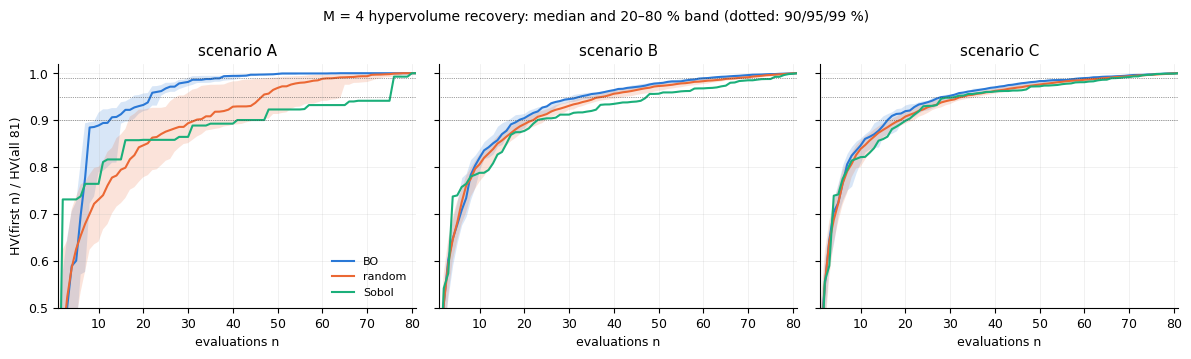

In [9]:
def plot_hv(store, fname, title):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
    n = np.arange(1, 82)
    for ax, t in zip(axes, R.SCENARIOS):
        for k in ("BO", "random", "Sobol"):
            med, lo, hi = R.band(store[t]["curves"][k])
            ax.plot(n, med, color=COL[k], lw=1.5, label=k)
            if k != "Sobol": ax.fill_between(n, lo, hi, color=COL[k], alpha=0.18, lw=0)
        for lvl in R.HV_LEVELS: ax.axhline(lvl, color="#444", lw=0.5, ls=":")
        ax.set_title(f"scenario {t}"); ax.set_xlabel("evaluations n"); ax.set_ylim(0.5, 1.02); ax.set_xlim(1, 81)
    axes[0].set_ylabel("HV(first n) / HV(all 81)"); axes[0].legend(frameon=False, fontsize=8, loc="lower right")
    fig.suptitle(title, fontsize=10); fig.tight_layout()
    for ext in ("pdf", "png"): fig.savefig(FIGS / f"{fname}.{ext}", dpi=150)
    plt.show()
plot_hv(MO, "fig2_hv_recovery_M4", "M = 4 hypervolume recovery: median and 20–80 % band (dotted: 90/95/99 %)")

### 3b. Supplementary: cost–shed (M = 2) recovery

With 71–73 of 81 cells non-dominated in 4-D, M = 4 recovery is mostly a coverage
count and no ordering can beat random by much. The 2-D cost–shed front (the 19b
comparison, 4 / 23 / 24 cells) is where trade-off recovery is measurable. Same loop,
objectives restricted to {cost, shed}; reference built the same way on those two columns.

scenario    ideal_cost    ideal_shed    nadir_cost   nadir_shed      ref_cost    ref_shed       hv_all
       A -3.216795e+07 -12109.295345 -3.324272e+06   619.478263 -4.399035e+05 1892.355624 4.332854e+11
       B  4.451115e+06 -33870.429748  4.014292e+07  -232.630800  4.371210e+07 3131.149095 1.021023e+12
       C  4.004157e+06 -38579.876553  4.956807e+07 -1397.641053  5.412446e+07 2320.582497 1.515644e+12
scenario  level  BO_median BO_IQR  random_median random_IQR  Sobol_median Sobol_IQR
       A   0.90        8.0   7–10           24.0      16–32          31.0     31–31
       A   0.95        8.0   7–10           45.5      20–59          76.0     76–76
       A   0.99       28.5  22–31           50.0      38–67          76.0     76–76
       B   0.90       14.0  11–15           16.0      14–20          16.0     16–16
       B   0.95       21.0  19–25           31.0      28–37          36.0     36–36
       B   0.99       43.5  38–48           62.0      57–69          77.0     77–77


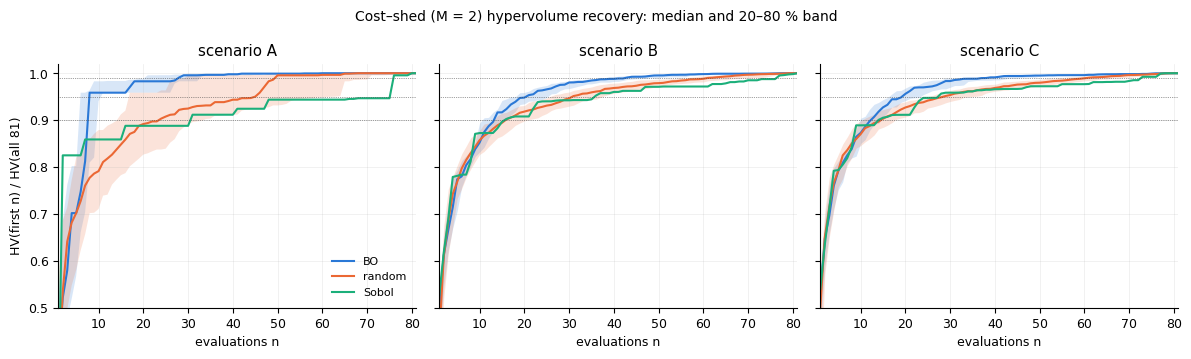

In [10]:
t0 = time.time()
MO2 = {}; rows = []
for t in R.SCENARIOS:
    X, Y = XY[t]; Y2 = Y[:, [0, 2]]; h = R.hv_reference(Y2); hv_all = hypervolume_exact(Y2, h["ref"])
    rows.append(dict(scenario=t, ideal_cost=h["ideal"][0], ideal_shed=h["ideal"][1], nadir_cost=h["nadir"][0], nadir_shed=h["nadir"][1],
                     ref_cost=h["ref"][0], ref_shed=h["ref"][1], hv_all=hv_all))
    bo = Parallel(n_jobs=-1)(delayed(R.parego_order)(X, Y2, s) for s in BO_SEEDS)
    orders = {"BO": bo, "random": [R.random_order(81, s) for s in RAND_SEEDS], "Sobol": [R.sobol_order(X)]}
    curves = {k: np.array([R.hv_curve(od, Y2, h["ref"], hv_all) for od in v]) for k, v in orders.items()}
    MO2[t] = {"orders": orders, "curves": curves, "ref": h}
hvref2 = pd.DataFrame(rows); hvref2.to_csv("hv_reference_costshed.csv", index=False); print(hvref2.to_string(index=False))
hvrec2 = hv_table(MO2, "costshed"); print(hvrec2.to_string(index=False))
print(f"cost-shed replay: {time.time() - t0:.0f} s")
RESULTS["hv_reference_costshed"] = hvref2.to_dict("records"); RESULTS["hv_recovery_costshed"] = hvrec2.to_dict("records")
plot_hv(MO2, "fig3_hv_recovery_costshed", "Cost–shed (M = 2) hypervolume recovery: median and 20–80 % band")

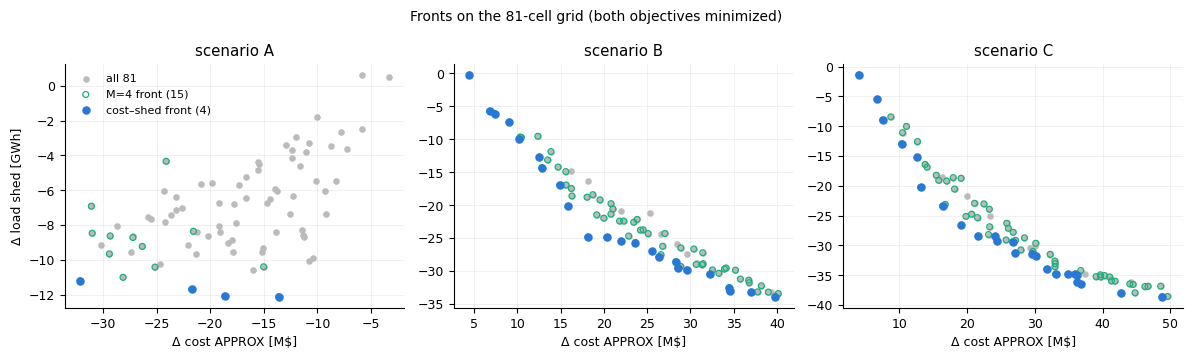

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, t in zip(axes, R.SCENARIOS):
    X, Y = XY[t]; m2 = R.front_mask(Y[:, [0, 2]]); m4 = R.front_mask(Y)
    ax.scatter(Y[:, 0] * 1e-6, Y[:, 2] * 1e-3, s=14, color="#bbb", label="all 81", zorder=1)
    ax.scatter(Y[m4, 0] * 1e-6, Y[m4, 2] * 1e-3, s=18, facecolors="none", edgecolors=COL["Sobol"], lw=0.9, label=f"M=4 front ({m4.sum()})", zorder=2)
    ax.scatter(Y[m2, 0] * 1e-6, Y[m2, 2] * 1e-3, s=26, color=COL["BO"], label=f"cost–shed front ({m2.sum()})", zorder=3)
    ax.set_xlabel("Δ cost APPROX [M$]"); ax.set_title(f"scenario {t}")
axes[0].set_ylabel("Δ load shed [GWh]"); axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Fronts on the 81-cell grid (both objectives minimized)", fontsize=10); fig.tight_layout()
for ext in ("pdf", "png"): fig.savefig(FIGS / f"fig4_fronts.{ext}", dpi=150)
plt.show()

## 4. q-ParEGO (bo-gp T-M8) smoke on scenario C, replay mode

`bogp.mobo.qparego.run_mobo_qparego` in candidates mode (acquisition argmax over
unqueried cells), n₀ = 8 random cells, q = 8, 2 rounds → 24 evaluations. Same
no-leakage rules (its normalization uses the queried ideal/nadir only). HV recovery
at n = 8 / 16 / 24 vs the Task-1 sequential loop and random at the same n.

In [12]:
import logging, torch
logging.getLogger("bogp").setLevel(logging.WARNING)
torch.set_num_threads(4)
t = "C"; X, Y = XY[t]; ref = HVREF[t]["ref"]; hv_all = HVREF[t]["hv_all"]
ev = MultiGridEvaluator(X, {o: Y[:, j] for j, o in enumerate(R.OBJECTIVES)})
Q_SEEDS = list(range(10)); N0, Q, ROUNDS = 8, 8, 2
t0 = time.time(); qcurves = []; qlog = []
for s in Q_SEEDS:
    init = np.random.default_rng(s).choice(81, N0, replace=False)
    res = QP.run_mobo_qparego(X[init], Y[init], ev, candidates=X, q=Q, n_rounds=ROUNDS, seed=s, ref_point=ref)
    assert res["Y_hist"].shape == (N0 + Q * ROUNDS, 4)
    assert len(np.unique(res["X_hist"], axis=0)) == N0 + Q * ROUNDS, "duplicate / re-queried cell"
    qcurves.append(np.array(res["hv_history"]) / hv_all)
    qlog.append(dict(seed=s, hv_n8=qcurves[-1][0], hv_n16=qcurves[-1][1], hv_n24=qcurves[-1][2], front_n24=int(res["pareto_mask"].sum())))
print(f"q-ParEGO smoke: {len(Q_SEEDS)} seeds × {ROUNDS} rounds × q={Q} in {time.time() - t0:.0f} s")
qc = np.array(qcurves)
seq = MO[t]["curves"]["BO"][:, [N0 - 1, N0 + Q - 1, N0 + 2 * Q - 1]]
rnd = MO[t]["curves"]["random"][:, [N0 - 1, N0 + Q - 1, N0 + 2 * Q - 1]]
smoke = pd.DataFrame({"n": [N0, N0 + Q, N0 + 2 * Q],
    "qParEGO_q8_median": np.median(qc, 0), "qParEGO_q8_IQR": [f"{a:.3f}–{b:.3f}" for a, b in zip(np.percentile(qc, 25, 0), np.percentile(qc, 75, 0))],
    "sequential_median": np.median(seq, 0), "sequential_IQR": [f"{a:.3f}–{b:.3f}" for a, b in zip(np.percentile(seq, 25, 0), np.percentile(seq, 75, 0))],
    "random_median": np.median(rnd, 0), "random_IQR": [f"{a:.3f}–{b:.3f}" for a, b in zip(np.percentile(rnd, 25, 0), np.percentile(rnd, 75, 0))]})
smoke.to_csv("qparego_smoke_C.csv", index=False); print(smoke.round(4).to_string(index=False))
RESULTS["qparego_smoke_C"] = {"seeds": Q_SEEDS, "n0": N0, "q": Q, "rounds": ROUNDS, "table": smoke.to_dict("records"), "per_seed": qlog}

q-ParEGO smoke: 10 seeds × 2 rounds × q=8 in 47 s
 n  qParEGO_q8_median qParEGO_q8_IQR  sequential_median sequential_IQR  random_median  random_IQR
 8             0.8134    0.783–0.820             0.8242    0.780–0.842         0.8068 0.784–0.827
16             0.8994    0.886–0.915             0.8999    0.872–0.913         0.8848 0.873–0.896
24             0.9407    0.923–0.947             0.9355    0.921–0.940         0.9228 0.914–0.932


## 5. Leakage self-check and results dump

In [13]:
src = Path("replay.py").read_text().splitlines()
fits = [(i + 1, l.strip()) for i, l in enumerate(src) if ".fit(" in l]
for ln, l in fits: print(f"replay.py:{ln}: {l}")
print("\nEvery .fit( receives X[q]/y[q] (queried rows) or the scaled queried inputs inside QueriedGP.fit — no full-table fit.")
RESULTS["fit_calls"] = [f"replay.py:{ln}: {l}" for ln, l in fits]
RESULTS["wall_clock_s"] = round(time.time() - T0)
Path("replay_results.json").write_text(json.dumps(RESULTS, indent=1, default=lambda o: o.item() if hasattr(o, "item") else str(o)))
print(f"\ntotal wall clock: {RESULTS['wall_clock_s']} s; results -> replay_results.json")

replay.py:9: points queried so far. Nothing here calls `.fit(` on the full table; the
replay.py:215: self._gpr.fit((Xq - self._lo) / self._span, np.asarray(yq, float))
replay.py:257: gp.fit(X[q], y[q])                      # queried points only
replay.py:286: gp.fit(X[q], g)

Every .fit( receives X[q]/y[q] (queried rows) or the scaled queried inputs inside QueriedGP.fit — no full-table fit.

total wall clock: 205 s; results -> replay_results.json
